<p><img alt="Colaboratory logo" height="160px" src="https://upload.wikimedia.org/wikipedia/commons/c/ce/Logo-ITM-01.png" align="left" hspace="10px" vspace="0px"></p>

</small>***Visualizacion de Datos - medellin-traffic-accidents-analisis***</small>

Ignacio Joaquín Pérez Chaves   
https: //github.com/ignacioperez1504/medellin-traffic-accidents-analisis  
Facultad de Ingenieria   
Instituto Tecnologico Metropolitano(ITM)    
2026

***<h3> Analisis Exploratorio de Datos: </h3>***

In [75]:
#@title Cargando la base de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

path='D:\ITM-------WORKSPACE\Visualizacion_de_Datos\incidentes_viales.csv'

dta=pd.read_csv(path)
dta.head(5)

C:\Users\ignac\AppData\Local\Temp\ipykernel_25352\900424573.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dta=pd.read_csv(path)


,AÑO,CBML,CLASE_ACCIDENTE,DIRECCION,DIRECCION ENCASILLADA,DISEÑO,EXPEDIENTE,FECHA_ACCIDENTE,FECHA_ACCIDENTES,GRAVEDAD_ACCIDENTE,MES,NRO_RADICADO,NUMCOMUNA,BARRIO,COMUNA,LOCATION,X,Y
0,2015,1013,Caida Ocupante,CR 46 CL 43,CR 046 043 000 00000,Tramo de via,A000259731,21/10/2015 05:58:00,2015-10-21T10:58:00.000Z,Con heridos,10,1508668,10,Barrio Colón,La Candelaria,"[-75.5688011014, 6.24312304123]",834949.69,1182357.34
1,2015,1020,Choque,CR 43 A CL 29,CR 043 A 029 000 00000,Tramo de via,A000261725,05/11/2015 03:00:00,2015-11-05T08:00:00.000Z,Solo daños,11,1510621,10,San Diego,La Candelaria,"[-75.5693883283, 6.22870030622]",834880.17,1180762.02
2,2015,0205,Otro,CR 46 CL 37,CR 046 037 000 00000,Tramo de via,A000259739,21/10/2015 07:40:00,2015-10-21T12:40:00.000Z,Con heridos,10,1508691,02,La Francia,Santa Cruz,"[-75.5503911403, 6.29869502502]",837004.94,1188499.17
3,2015,0101,Atropello,CR 34 CL 112,CR 034 112 000 00000,Tramo de via,A000259752,21/10/2015 12:00:00,2015-10-21T17:00:00.000Z,Con heridos,10,1508694,01,Santo Domingo Savio No. 1,Popular,"[-75.5442195069, 6.30019383306]",837688.53,1188663.05
4,2015,1504,Choque,CR 50 CL 14,CR 050 014 000 00000,Tramo de via,A000259949,03/11/2015 06:16:00,2015-11-03T11:16:00.000Z,Solo daños,11,1510634,15,Santa Fé,Guayabal,"[-75.578180998, 6.21699243701]",833903.11,1179469.60


In [76]:
dta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270765 entries, 0 to 270764
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AÑO                    270765 non-null  object 
 1   CBML                   252609 non-null  object 
 2   CLASE_ACCIDENTE        270759 non-null  object 
 3   DIRECCION              270765 non-null  object 
 4   DIRECCION ENCASILLADA  270374 non-null  object 
 5   DISEÑO                 269617 non-null  object 
 6   EXPEDIENTE             270655 non-null  object 
 7   FECHA_ACCIDENTE        270765 non-null  object 
 8   FECHA_ACCIDENTES       270765 non-null  object 
 9   GRAVEDAD_ACCIDENTE     270765 non-null  object 
 10  MES                    270765 non-null  int64  
 11  NRO_RADICADO           270760 non-null  object 
 12  NUMCOMUNA              270765 non-null  object 
 13  BARRIO                 251759 non-null  object 
 14  COMUNA                 257967 non-nu

In [77]:
for col, val in dta.isna().sum().items():
    print(f"'{col}': {int(val)}")

'AÑO': 0
'CBML': 18156
'CLASE_ACCIDENTE': 6
'DIRECCION': 0
'DIRECCION ENCASILLADA': 391
'DISEÑO': 1148
'EXPEDIENTE': 110
'FECHA_ACCIDENTE': 0
'FECHA_ACCIDENTES': 0
'GRAVEDAD_ACCIDENTE': 0
'MES': 0
'NRO_RADICADO': 5
'NUMCOMUNA': 0
'BARRIO': 19006
'COMUNA': 12798
'LOCATION': 0
'X': 0
'Y': 0


***<h3> Estudio de Fecha y Hora del accidente: </h3>***

 ***La siganterior Warning nos recomienda ver la columna 0 debido a que tiene una combinacion de Types:***

 </small>`//DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dta=pd.read_csv(path)`</small>



In [78]:
dta['AÑO'].unique()

array(['2015', '2014', '2016', '2017', '2018', '2019\\r', '2019', '2020',
       2020, 2015, 2014, 2016, 2017, 2018], dtype=object)

</small> Podemos ver que la columna tiene variables tipo str, int en particual '2019\\r' es distinta. Aunque la solucion seria normalizar estos valores no se procedera debido aq ue se eliminara la columa entera </small>

In [79]:
dta = dta.drop(columns=['AÑO', 'MES', 'FECHA_ACCIDENTES'])

</small> La decision fue tomada debido a que esa misma informacion se encuetra en una sola columna llamada: ***FECHA_ACCIDENTE***</small>

***NOTA:*** Debido a que ***FECHA_ACCIDENTE*** no contiene nulos se intento convertir la info en Datetime no me percate de que el contenido puede ser distienot de un nulo y de un datetime como por ejemplo basura

In [80]:
dta['FECHA_ACCIDENTE'] = pd.to_datetime(
    dta['FECHA_ACCIDENTE'],
    errors='coerce',   # coerse nos va a convertir directamente esa basura a NaT (Not a time)
    dayfirst=True
)


</small>  Eliminacion de nulos y cambio del tipo de variable: </small> 

In [81]:
print(dta['FECHA_ACCIDENTE'].isna().sum())   #Se perderian tan solo 6 registros. Eso es muchisimo menos del 1% de la informacion ---> Se borran los nulos
dta = dta.dropna(subset=['FECHA_ACCIDENTE'])

dta['FECHA_ACCIDENTE'].dtype

6


dtype('<M8[ns]')

***<h3> Estudio demas variables complementarias: </h3>***

In [82]:
#Veamos quesi queremos una columna de identificacion del # de caso del accidente el NRO_RADICANDO es el mejor. Se eliminara la columna EXPEDIENTE
print(f"Estos son todos los distintos de NRO_RADICADO: {dta['NRO_RADICADO'].nunique()} y estos lo de EXPEDIENTE: {dta['EXPEDIENTE'].nunique()} ")
dta = dta.drop(columns=['EXPEDIENTE'])

Estos son todos los distintos de NRO_RADICADO: 270725 y estos lo de EXPEDIENTE: 270151 


In [83]:
dta['CLASE_ACCIDENTE'].unique()

map_class= {
    'Caida Ocupante' : 'Caida Ocupante',
    'Caída de Ocupante' : 'Caida Ocupante',
    'Caida de Ocupante' : 'Caida Ocupante',
    'Caída Ocupante' : 'Caida Ocupante',
    'Choque': 'Choque',
    'Otro': 'Otro',
    'Atropello': 'Atropello',
    'Volcamiento': 'Volcamiento',
    'Incendio': 'Incendio',
    'nan': None,
}

dta['CLASE_ACCIDENTE'] = dta['CLASE_ACCIDENTE'].map(map_class)


In [84]:
dta['GRAVEDAD_ACCIDENTE'].unique()

map_grav= {
    'Con heridos': 'Con heridos',
    'Solo daños': 'Solo daños',
    'Con muertos': 'Fallecidos',
    'Solo da\\xF1os': 'Solo daños',
}

dta['GRAVEDAD_ACCIDENTE']=dta['GRAVEDAD_ACCIDENTE'].map(map_grav)

***<h3> Estudio de Ubicacion del Accidente : </h3>***

***Analisis Ubicacion:***  Al hacer una debida inspeccion se noto que los valores de ***LOCATION*** oscilan al rededos de los [-75, 6] valores de coordenadas geogrficas de colombia mas en especifico medellin por lo que estos valores corresponden a valores exatos de ubicacion. Para una mayor precision y despues de investigar, los valores que aparecen como X , Y son valores de coordenadas cartesianas que usan ingenieros, topografos y la Alcaldia de Medellín en sus mapas oficiales para referenciar ubicaicones exactas en metros con respecto a cierto origen cuyo ubicacion es conocida.


In [85]:
#Para facilitar el estudio y en terminos mas generales se eliminara esta informacion de ubicacion exacta del accidente de esa manera hacer un estudio por zonas de medellin
dta = dta.drop(columns=['LOCATION', 'X', 'Y','DIRECCION ENCASILLADA'])
dta = dta[[
    'FECHA_ACCIDENTE',
    'NRO_RADICADO',
    'CLASE_ACCIDENTE',
    'GRAVEDAD_ACCIDENTE',
    'DISEÑO',
    'DIRECCION',
    'BARRIO',
    'COMUNA',
    'NUMCOMUNA',
    'CBML'
]]
dta.head()

,FECHA_ACCIDENTE,NRO_RADICADO,CLASE_ACCIDENTE,GRAVEDAD_ACCIDENTE,DISEÑO,DIRECCION,BARRIO,COMUNA,NUMCOMUNA,CBML
0,2015-10-21 05:58:00,1508668,Caida Ocupante,Con heridos,Tramo de via,CR 46 CL 43,Barrio Colón,La Candelaria,10,1013
1,2015-11-05 03:00:00,1510621,Choque,Solo daños,Tramo de via,CR 43 A CL 29,San Diego,La Candelaria,10,1020
2,2015-10-21 07:40:00,1508691,Otro,Con heridos,Tramo de via,CR 46 CL 37,La Francia,Santa Cruz,02,0205
3,2015-10-21 12:00:00,1508694,Atropello,Con heridos,Tramo de via,CR 34 CL 112,Santo Domingo Savio No. 1,Popular,01,0101
4,2015-11-03 06:16:00,1510634,Choque,Solo daños,Tramo de via,CR 50 CL 14,Santa Fé,Guayabal,15,1504


In [86]:
dta['COMUNA'].unique()

array(['La Candelaria', 'Santa Cruz', 'Popular', 'Guayabal', 'El Poblado',
       'Laureles Estadio', 'Robledo', 'Doce de Octubre', 'Aranjuez',
       'Buenos Aires', 'Castilla',
       'Corregimiento de San Antonio de Prado', nan, 'San Javier',
       'Villa Hermosa', 'Belén', 'Manrique', 'La América',
       'Corregimiento de Altavista', 'Corregimiento de San Cristóbal',
       'Corregimiento de Santa Elena', 'In', 'SN', 'No Georef',
       'Corregimiento de San Sebastián de Palmitas', 'Bel\\xE9n',
       'La Am\\xE9rica', 'Corregimiento de San Crist\\xF3bal',
       'Corregimiento de San Sebasti\\xE1n de Palmitas', 'Sin Inf', '0',
       'AU'], dtype=object)

</small>  Mapeo de correccion de formatos y errores: </small> 

In [87]:
map_comuna = {
    # Comunas
    'La Candelaria': 'La Candelaria', 
    'Santa Cruz': 'Santa Cruz', 
    'Popular': 'Popular', 
    'Guayabal': 'Guayabal',
    'El Poblado': 'El Poblado', 
    'Laureles Estadio': 'Laureles–Estadio', 
    'Robledo': 'Robledo', 
    'Doce de Octubre': 'Doce de Octubre', 
    'Aranjuez': 'Aranjuez',
    'Buenos Aires': 'Buenos Aires', 
    'Castilla': 'Castilla', 
    'San Javier': 'San Javier', 
    'Villa Hermosa': 'Villa Hermosa', 
    'Belén': 'Belén', 
    'Manrique': 'Manrique',
    'La América': 'La América', 

    # problemas de encoding
    'La Am\\xE9rica': 'La América',
    'Bel\\xE9n': 'Belén',
    'Corregimiento de San Crist\\xF3bal': 'San Cristóbal',
    'Corregimiento de San Sebasti\\xE1n de Palmitas': 'San Sebastián de Palmitas',

    # Corregimientos
    'Corregimiento de San Antonio de Prado': 'San Antonio de Prado', #80
    'Corregimiento de Altavista': 'Altavista',#70
    'Corregimiento de San Cristóbal': 'San Cristóbal', #60
    'Corregimiento de Santa Elena': 'Santa Elena', #90 
    'Corregimiento de San Sebastián de Palmitas': 'San Sebastián de Palmitas' #50
}

In [88]:
dta['COMUNA'] = dta['COMUNA'].map(map_comuna)

#Despues del mapeo nos damos cuenta que la cantidad de nulos supera el 5% de los datos una cantidad considerable por lo que se va a obtar por implementar una estrategia para mejorar este dato
dta['COMUNA'].isna().sum()

19861

***<h3> Estrategias de complementacion de registros : </h3>***

***Primera estrategia:*** </small> Se busca completar la columna comuna para eso me apoyare en la columna direccion que tiene menos registro en nulos. De esa manera buscar completar comuna con una direccion ya registrada</small> 

In [89]:
map_dir_comuna = (
    dta.dropna(subset=['COMUNA'])
       .groupby('BARRIO')['COMUNA']
       .agg(lambda x: x.iloc[0] if x.nunique() == 1 else None)
)

dta['COMUNA'] = dta['COMUNA'].fillna(
    dta['DIRECCION'].map(map_dir_comuna)
)

dta['COMUNA'].isna().sum()

19860

***Segunda estrategia:*** </small> Se realizara el mimsmo proceso, ahora con la columna barrio</small> 

In [90]:
map_bar_comuna = (
    dta.dropna(subset=['COMUNA'])
       .groupby('BARRIO')['COMUNA']
       .agg(lambda x: x.iloc[0] if x.nunique() == 1 else None)
)

dta['COMUNA'] = dta['COMUNA'].fillna(
    dta['BARRIO'].map(map_bar_comuna)
)

dta['COMUNA'].isna().sum()

19856

***Tercera estrategia:*** </small> Complemento con la columna num_comuna</small> 

In [91]:
dta['NUMCOMUNA'].unique()

array(['10', '02', '01', '15', '14', '11', '07', '06', '04', '09', '05',
       '80', 'Sin Inf', '13', '08', '16', '03', '12', '70', '60', '90',
       'In', 'SN', '0', '50', 'AU', '5', '7', '9', '4', '3', '1', '2',
       '8', '6'], dtype=object)

In [92]:
map_numero_comuna = {
    #Comunas
    '1': 1, '01': 1,
    '2': 2, '02': 2,
    '3': 3, '03': 3,
    '4': 4, '04': 4,
    '5': 5, '05': 5,
    '6': 6, '06': 6,
    '7': 7, '07': 7,
    '8': 8, '08': 8,
    '9': 9, '09': 9,
    '10': 10,
    '11': 11,
    '12': 12,
    '13': 13,
    '14': 14,
    '15': 15,
    '16': 16,

    # Corregimientos
    '50': 50,
    '60': 60,
    '70': 70,
    '80': 80,
    '90': 90
}

In [93]:
dta['NUMCOMUNA'] = dta['NUMCOMUNA'].map(map_numero_comuna)
print(dta['NUMCOMUNA'].isna().sum())

20126


In [94]:
map_num_to_comuna = (
    dta.dropna(subset=['COMUNA', 'NUMCOMUNA'])
       .groupby('NUMCOMUNA')['COMUNA']
       .agg(lambda x: x.iloc[0] if x.nunique() == 1 else None)
       .dropna()
       .to_dict()
)

In [95]:
map_comuna_to_num = (
    dta.dropna(subset=['COMUNA', 'NUMCOMUNA'])
       .groupby('COMUNA')['NUMCOMUNA']
       .agg(lambda x: x.iloc[0] if x.nunique() == 1 else None)
       .dropna()
       .to_dict()
)

In [96]:
dta['NUMCOMUNA'] = dta['NUMCOMUNA'].fillna(
    dta['COMUNA'].map(map_comuna_to_num)
)
dta['COMUNA'] = dta['COMUNA'].fillna(
    dta['NUMCOMUNA'].map(map_num_to_comuna)
)

In [97]:
print(dta['NUMCOMUNA'].isna().sum())
print(dta['COMUNA'].isna().sum())

19830
19830


 ***Despues de la ejecucion:***

 </small>`No se logro conseguir un metodo que completara los nulos de la columna comuna`</small>   
 El valor de `16003` corresponde exactamente al `5.9%` del espacio muestral


***Decision:***

 </small>Debido a que los valores faltantes corresponden  variables condicionadas,ejemplo: Pueden depender de zona geografica, tipo de accidente, etc... , se puede orientar el estudio de esta de esta falta de informacion, se mantendran los valores fatlatantes y se creara una columna `COMUNA_NA` para el analisis</small>   
 

In [98]:
dta['COMUNA_NA'] = dta['COMUNA'].isna()

***<h3> Tratamiento de nulos : </h3>***

In [99]:
dta.duplicated().sum()
dta = dta.drop_duplicates()

***<h2> Visualizacion: </h2>***

In [100]:
dta.columns.tolist()

['FECHA_ACCIDENTE',
 'NRO_RADICADO',
 'CLASE_ACCIDENTE',
 'GRAVEDAD_ACCIDENTE',
 'DISEÑO',
 'DIRECCION',
 'BARRIO',
 'COMUNA',
 'NUMCOMUNA',
 'CBML',
 'COMUNA_NA']

In [101]:
d1=dta['FECHA_ACCIDENTE'].min()
d2=dta['FECHA_ACCIDENTE'].max()
print(f"Este es la fehca de primer registro: {d1}, y esta es la fecha de ultimo registro: {d2}")

Este es la fehca de primer registro: 2014-07-04 05:40:00, y esta es la fecha de ultimo registro: 2020-08-31 21:45:00


In [102]:
bins_dias = abs((d2 - d1).days)
bins_meses = abs((d2.to_period('M') - d1.to_period('M')).n)  # meses totales
bins_anios = abs(d2.year - d1.year)

</small>***¿Cómo se distribuyen los incidentes viales en el tiempo?***</small>


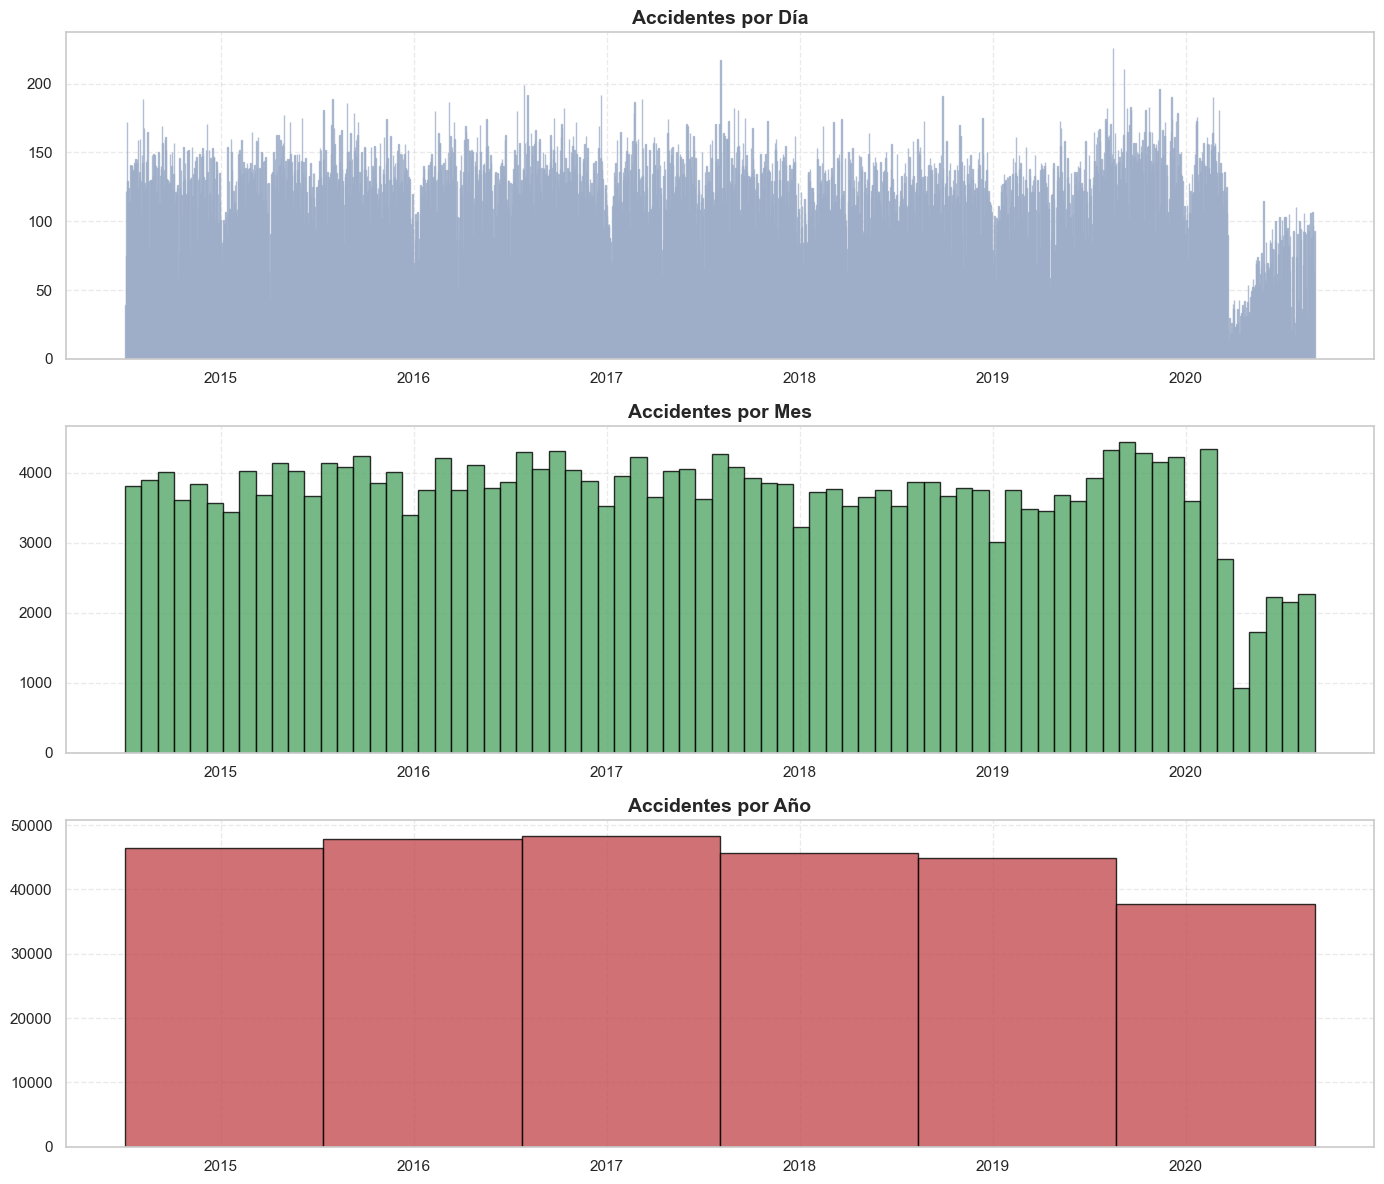

In [103]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)


axes[0].hist(
    dta['FECHA_ACCIDENTE'],
    bins=bins_dias,
    color="#9EAEC8",
    alpha=0.8,
    edgecolor="#9EAEC8"
)
axes[0].set_title("Accidentes por Día", fontsize=14, weight="bold")
axes[0].grid(True, linestyle="--", alpha=0.4)


axes[1].hist(
    dta['FECHA_ACCIDENTE'],
    bins=bins_meses,
    color="#55A868",
    alpha=0.8,
    edgecolor="black"
)
axes[1].set_title("Accidentes por Mes", fontsize=14, weight="bold")
axes[1].grid(True, linestyle="--", alpha=0.4)


axes[2].hist(
    dta['FECHA_ACCIDENTE'],
    bins=bins_anios,
    color="#C44E52",
    alpha=0.8,
    edgecolor="black"
)
axes[2].set_title("Accidentes por Año", fontsize=14, weight="bold")
axes[2].grid(True, linestyle="--", alpha=0.4)


plt.tight_layout()
plt.show()

</small>***¿Qué comunas o zonas presentan más incidentes?***</small>


In [104]:
dta_com_acc = (
    dta.groupby('COMUNA')
       .size()
       .reset_index(name='N_ACCIDENTES')
)

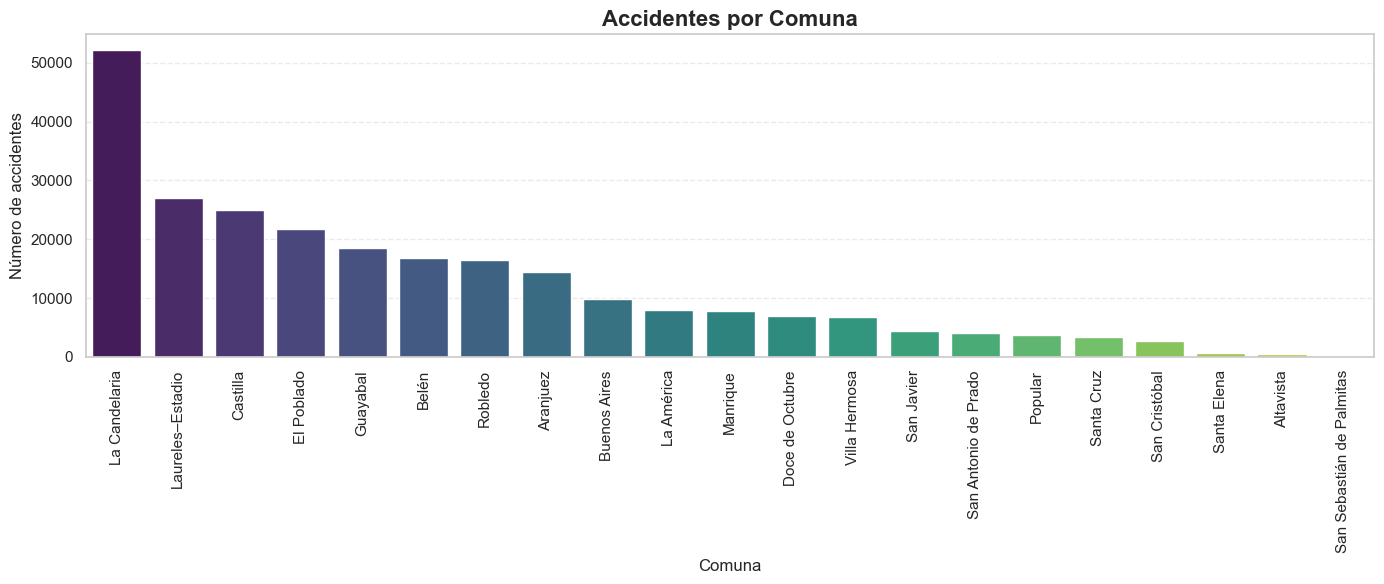

In [105]:
dta_com_acc = dta_com_acc.sort_values('N_ACCIDENTES', ascending=False)  

# Estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.barplot(
    data=dta_com_acc,
    x='COMUNA',
    y='N_ACCIDENTES',
    palette="viridis"
)

plt.title("Accidentes por Comuna", fontsize=16, weight="bold")
plt.xlabel("Comuna")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=90) 
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

</small>***¿Qué tipos de accidente y niveles de gravedad aparecen con mayor frecuencia?***</small>


In [106]:
dta_class_grav = pd.crosstab(
    dta['CLASE_ACCIDENTE'],
    dta['GRAVEDAD_ACCIDENTE']
)

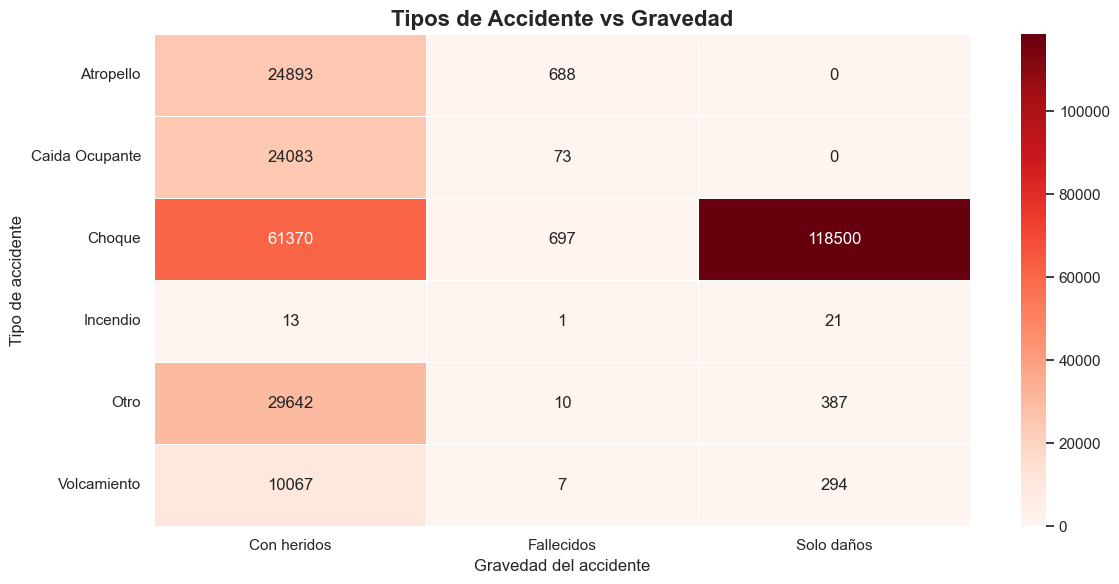

In [107]:
plt.figure(figsize=(12,6))

sns.heatmap(
    dta_class_grav,
    annot=True,        # muestra números
    fmt="d",           # formato entero
    cmap="Reds",       # colores tipo intensidad
    linewidths=0.5
)

plt.title("Tipos de Accidente vs Gravedad", fontsize=16, weight="bold")
plt.xlabel("Gravedad del accidente")
plt.ylabel("Tipo de accidente")

plt.tight_layout()
plt.show()

</small>***¿Se observan patrones por mes, día de la semana u hora, si esas variables están disponibles o pueden derivarse?***</small>


</small>***Mes:***</small>


In [111]:
dta_mes = (
    dta['FECHA_ACCIDENTE']
    .dt.month
    .value_counts()
)

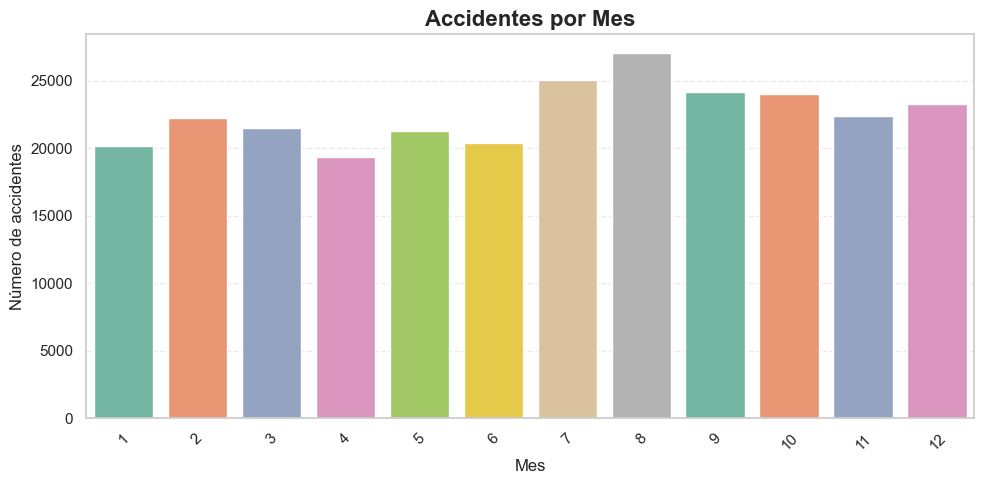

In [119]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.barplot(
    x=dta_mes.index,
    y=dta_mes.values,
    palette="Set2"
)

plt.title("Accidentes por Mes", fontsize=16, weight="bold")
plt.xlabel("Mes")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

</small>***Dia:***</small>


</small>como puedo convertir las fechas en dias de la semana?</small>

In [108]:
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dta_dia_semana = (
    dta['FECHA_ACCIDENTE']
    .dt.day_name()
    .value_counts()
    .reindex(orden)
)

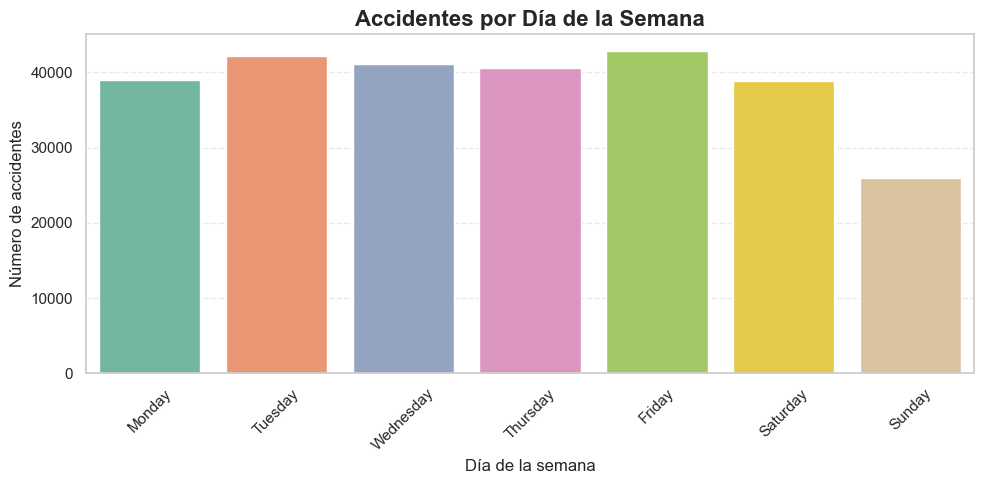

In [121]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.barplot(
    x=dta_dia_semana.index,
    y=dta_dia_semana.values,
    palette="Set2"
)

plt.title("Accidentes por Día de la Semana", fontsize=16, weight="bold")
plt.xlabel("Día de la semana")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

</small>***Hora:***</small>


In [110]:
dta_hora = (
    dta['FECHA_ACCIDENTE']
    .dt.hour
    .value_counts()
)

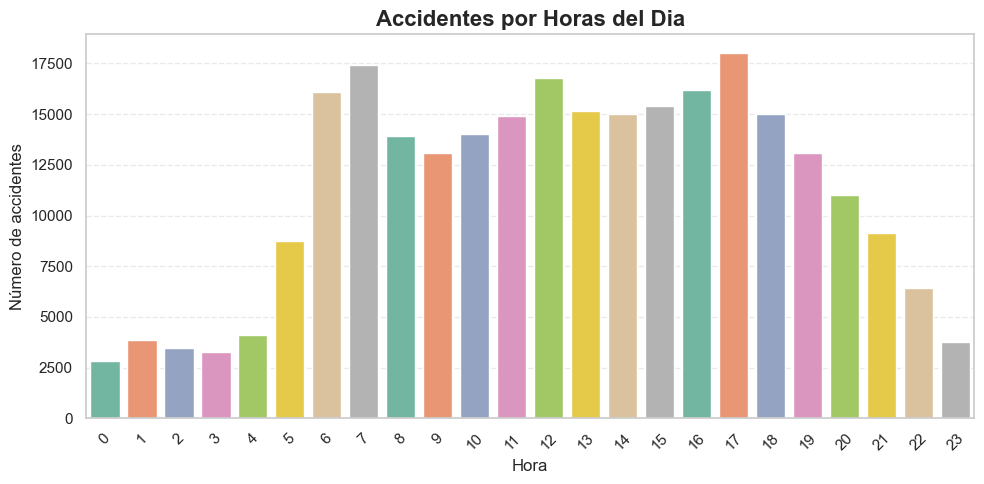

In [120]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.barplot(
    x=dta_hora.index,
    y=dta_hora.values,
    palette="Set2"
)

plt.title("Accidentes por Horas del Dia", fontsize=16, weight="bold")
plt.xlabel("Hora")
plt.ylabel("Número de accidentes")

plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

</small>***¿Existen relaciones o combinaciones relevantes entre ubicación, tipo de accidente y gravedad?***</small>


</small>***¿Qué hallazgos importantes o anomalías detecta en el dataset?***</small>

</small>***Pregunta***</small>